# Preprocesamiento

El preprocesamiento mejora la calidad de la imagen (mejoramiento) de metafase antes de las etapas de análisis. En nuestro pipeline consiste en reducción de ruido (Non-Local Means) y realce de contraste local (CLAHE).

Este notebook documenta el preprocesamiento y muestra su efecto paso a paso, validándolo sobre varias imágenes.

## Nota: organización del código

La lógica funcional vive en Interfaz/pipeline/preprocessing.py, que es la fuente que usan tanto la interfaz como el entrenamiento del clasificador. Este notebook la importa y la documenta paso a paso.

## Por qué y dónde se aplica el preprocesamiento

Una decisión importante del pipeline es que el preprocesamiento no se aplica antes de la segmentación, sino en la rama que alimenta la clasificación. La razón es la consistencia entre entrenamiento e inferencia: el preprocesamiento debe ser el mismo en ambos momentos.

El modelo de segmentación se entrenó sobre las imágenes crudas. Detectron2 ya aplica internamente una normalización de intensidad, los CNN profundos son robustos al ruido moderado, y las imágenes de AutoKary2022 son de por sí bastante limpias. La evidencia es que el modelo alcanza un AP50 del 97.8% entrenando sobre crudo. Si en inferencia le entregáramos una imagen fuertemente procesada, introduciríamos un desajuste respecto a lo que vio en entrenamiento, que podría degradar la segmentación.

Por eso el preprocesamiento se posiciona donde aporta valor sin romper esa consistencia: en la rama de clasificación. Los recortes de cada cromosoma son pequeños y ahí el realce de contraste ayuda. El mismo preprocesamiento debe usarse al generar los recortes de entrenamiento del clasificador.

En resumen, se segmenta sobre la imagen cruda y se recortan los cromosomas desde la imagen preprocesada.

## Preparación e importaciones

In [1]:
import os, sys
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Localizamos la raíz del repo (la carpeta que contiene Interfaz/).
REPO = os.getcwd()
while not os.path.isdir(os.path.join(REPO, "Interfaz")) and os.path.dirname(REPO) != REPO:
    REPO = os.path.dirname(REPO)
sys.path.insert(0, os.path.join(REPO, "Interfaz"))

from pipeline import preprocessing as pp
print("Parámetros canónicos:", pp.CANONICAL)

Parámetros canónicos: {'do_denoise': True, 'denoise_method': 'nlm', 'denoise_strength': 7.0, 'do_clahe': True, 'clahe_clip': 1.5, 'do_normalize': False}


## Preprocesamiento paso a paso

El preprocesamiento aplica en orden: conversión a escala de grises, denoising con Non-Local Means y realce de contraste con CLAHE. Los parámetros están fijos en pp.CANONICAL. A continuación se ve el efecto de cada paso sobre una imagen de test.

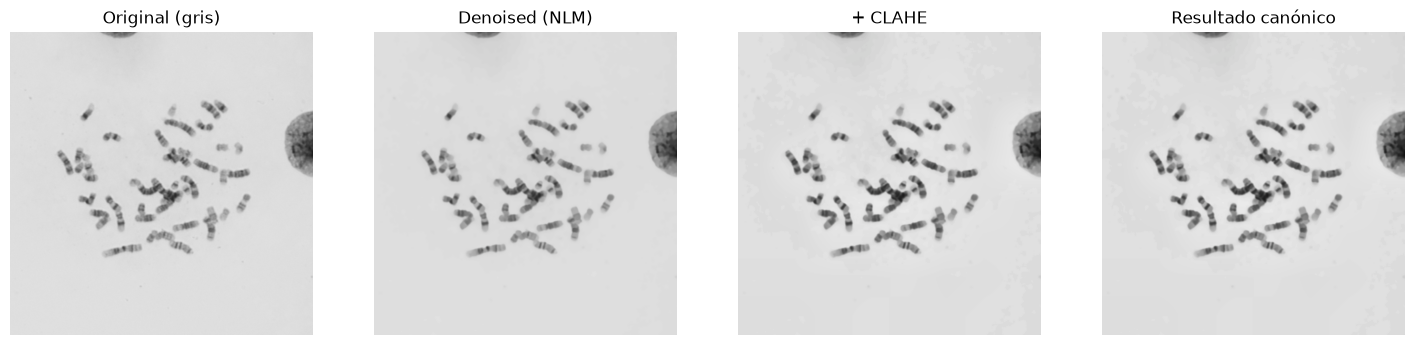

Ruido estimado (sigma, método de Immerkaer): 0.73 -> 0.15


In [2]:
IMG = os.path.join(REPO, "Datasets", "Autokary2022_1600x1600", "test_labelme",
                   "211025-003C", "211025-003C_129_1_688_378_0.461.png")
image = cv2.cvtColor(cv2.imread(IMG), cv2.COLOR_BGR2RGB)

steps = pp.preprocess(image, **pp.CANONICAL)

panels = [(steps["gray"], "Original (gris)"), (steps["denoised"], "Denoised (NLM)"),
          (steps["clahe"], "+ CLAHE"), (steps["result"], "Resultado canónico")]
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
for a, (im, t) in zip(ax, panels):
    a.imshow(im); a.set_title(t); a.axis("off")
plt.show()

print(f"Ruido estimado (sigma, método de Immerkaer): {steps['sigma_in']:.2f} -> {steps['sigma_out']:.2f}")

## Elección de los parámetros

Los parámetros se ajustaron observando el resultado sobre imágenes reales:

- Denoising Non-Local Means con intensidad 7: las imágenes de AutoKary2022 tienen muy poco ruido (sigma cercano a 0.7), y con esta intensidad el bandeo G de los cromosomas se preserva.
- CLAHE con clip bajo (1.5): un clip alto amplificaba el fondo casi uniforme en manchas grises. Con 1.5 se realza el bandeo sin ensuciar el fondo.
- Sin normalización global: estiraba el rango dinámico y amplificaba los artefactos del fondo. La normalización de intensidad, si hiciera falta, se hace por cromosoma en la etapa de extracción.

## Métricas de calidad antes y después

Cuantificamos el efecto del preprocesamiento con el PSNR y el SSIM entre la imagen original en escala de grises y la preprocesada.

In [3]:
psnr = pp.psnr(steps["gray"], steps["result"])
ssim = pp.ssim(steps["gray"], steps["result"])
print(f"PSNR: {psnr:.2f} dB")
print(f"SSIM: {ssim:.4f}")

PSNR: 33.05 dB
SSIM: 0.9691


## Validación sobre varias imágenes

Para confirmar que el preprocesamiento se comporta de forma consistente, lo aplicamos sobre imágenes de distintos pacientes y reportamos las métricas de cada una, más un montaje visual antes y después.

imagen                                   sigma_in sigma_out    PSNR    SSIM
211025-003C_129_1_688_378_0.461.png          0.73      0.15   33.05  0.9691
211029-023C_135_6_982_378_0.806.png          0.75      0.14   32.35  0.9710
107_1_590_345_0.505.png                      0.75      0.18   32.80  0.9685
142_1_345_411_0.671.png                      0.70      0.18   33.07  0.9650
0_2_247_180_0.811.png                        0.62      0.16   37.09  0.9681
0_1_247_180_0.880.png                        0.69      0.17   33.32  0.9680
105_2_492_345_0.879.png                      0.71      0.17   32.10  0.9679
10_2_737_180_0.821.png                       0.69      0.15   32.46  0.9690
154_1_933_411_0.549.png                      0.64      0.09   35.87  0.9739
118_3_1129_345_0.461.png                     0.66      0.11   34.41  0.9727


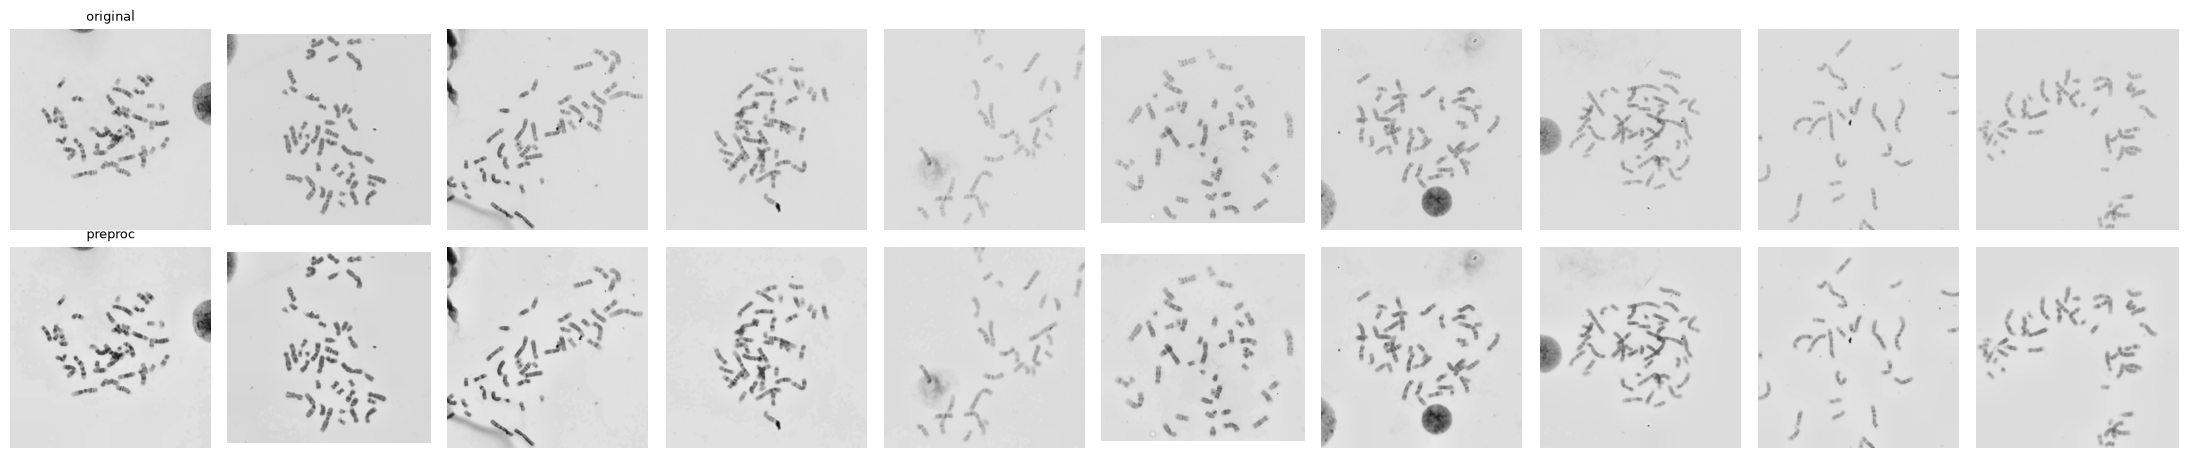

In [4]:
DATASET = os.path.join(REPO, "Datasets", "Autokary2022_1600x1600")

def sample_images(n):
    # Toma una imagen por paciente, espaciando la selección para tener variedad.
    paths = []
    for split in ("test_labelme", "train_labelme"):
        root = os.path.join(DATASET, split)
        if not os.path.isdir(root):
            continue
        for patient in sorted(os.listdir(root)):
            pdir = os.path.join(root, patient)
            if os.path.isdir(pdir):
                pngs = sorted(f for f in os.listdir(pdir) if f.endswith(".png"))
                if pngs:
                    paths.append(os.path.join(pdir, pngs[0]))
    if len(paths) <= n:
        return paths
    step = len(paths) / n
    return [paths[int(i * step)] for i in range(n)]

imgs = sample_images(10)
print(f"{'imagen':<40}{'sigma_in':>9}{'sigma_out':>10}{'PSNR':>8}{'SSIM':>8}")
rows = []
for p in imgs:
    im = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    st = pp.preprocess(im, **pp.CANONICAL)
    ps, ss = pp.psnr(st["gray"], st["result"]), pp.ssim(st["gray"], st["result"])
    rows.append((im, st["result"]))
    print(f"{os.path.basename(p)[:39]:<40}{st['sigma_in']:>9.2f}{st['sigma_out']:>10.2f}{ps:>8.2f}{ss:>8.4f}")

k = len(rows)
fig, ax = plt.subplots(2, k, figsize=(2.2 * k, 4.6))
for j, (orig, res) in enumerate(rows):
    ax[0, j].imshow(orig); ax[0, j].axis("off")
    ax[1, j].imshow(res); ax[1, j].axis("off")
ax[0, 0].set_title("original", fontsize=9)
ax[1, 0].set_title("preproc", fontsize=9)
plt.tight_layout()
plt.show()

## Conclusión

El preprocesamiento canónico se comporta de forma consistente en las distintas imágenes: reduce el ruido, realza el bandeo y mantiene el fondo limpio, con valores de SSIM por encima de 0.96. Estos parámetros quedan fijados como los canónicos del proyecto.

Los recortes de cromosomas para la clasificación se obtienen de la imagen preprocesada con esta misma configuración, que es la que debe usarse también al generar los recortes de entrenamiento del clasificador, para garantizar la consistencia entre entrenamiento e inferencia.